In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../datasets/new_ridership_data.csv')

df["Date"] = pd.to_datetime(df["Date"], format="%b %Y")

df_2 = df[df["Date"].dt.year >= 2021]

df_2

,Date,Ridership
24,2021-01-01,2670344
25,2021-02-01,2302010
26,2021-03-01,2844828
27,2021-04-01,2889673
28,2021-05-01,2861499
29,2021-06-01,2942437
30,2021-07-01,3001672
31,2021-08-01,2792914
32,2021-09-01,3597254
33,2021-10-01,3691081


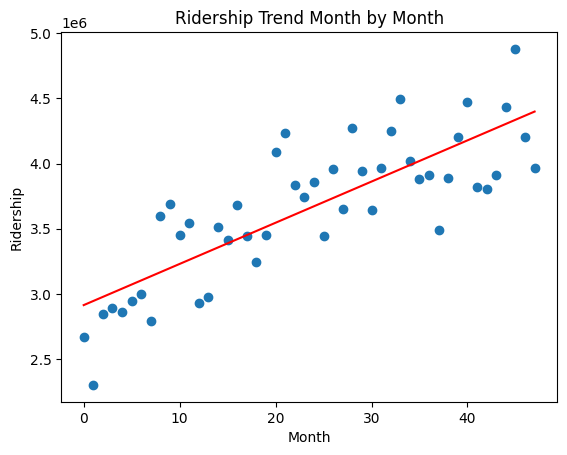

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     87.84
Date:                Wed, 05 Feb 2025   Prob (F-statistic):           3.07e-12
Time:                        13:46:50   Log-Likelihood:                -676.07
No. Observations:                  48   AIC:                             1356.
Df Residuals:                      46   BIC:                             1360.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.914e+06    9.2e+04     31.692      0.0

In [3]:
x = np.arange(len(df_2['Date'])).reshape(-1, 1)
y = np.array(df_2['Ridership']).reshape(-1, 1)


X = sm.add_constant(x)  
res = sm.OLS(y,X).fit()

y_pred = res.predict(X)


plt.scatter(x, y)
plt.plot(x, y_pred, color='red', label="OLS Fit")

plt.xlabel("Month")
plt.ylabel("Ridership")
plt.title("Ridership Trend Month by Month")

plt.show()

print(res.summary())

In [4]:
beta_0, beta_1 = res.params  

daily_x = np.arange(0,x.max()*30).reshape(-1, 1)

daily_y_pred = beta_1 * daily_x.flatten()

daily_df = pd.DataFrame({
    "Day_Index": daily_x.flatten(),
    "Ridership": daily_y_pred
})

# Save to CSV
path = "../datasets/daily_ridership.csv"
daily_df.to_csv(path, index=False)

print(f"Daily ridership dataset exported as {path}.")


Daily ridership dataset exported as ../datasets/daily_ridership.csv.
